# Q1-A: Precision: Pass = 0.790 | Fail = 0.632 (Precision (class) = TP / (TP + FP)


In [4]:
import pandas as pd

# rows = real class, columns = predicted class
cm = pd.DataFrame(
    [[160, 108],
     [93, 407]],
    index=["Fail", "Pass"],        # Real
    columns=["Pred_Fail", "Pred_Pass"]  # Predicted
)

cm

,Pred_Fail,Pred_Pass
Fail,160,108
Pass,93,407


In [5]:
# Precision = TP / (TP + FP)

# PASS as positive class
TP_pass = cm.loc["Pass", "Pred_Pass"]
FP_pass = cm.loc["Fail", "Pred_Pass"]
precision_pass = TP_pass / (TP_pass + FP_pass)

# FAIL as positive class
TP_fail = cm.loc["Fail", "Pred_Fail"]
FP_fail = cm.loc["Pass", "Pred_Fail"]
precision_fail = TP_fail / (TP_fail + FP_fail)

# --- Output ---
print(f"Precision (Pass) = {precision_pass:.3f}")
print(f"Precision (Fail) = {precision_fail:.3f}")

Precision (Pass) = 0.790
Precision (Fail) = 0.632


# Q1-B: Recall: Pass = 0.814 | Fail = 0.597 (Recall = TP / (TP + FN)


In [6]:
# --- Recall ---
# Recall = TP / (TP + FN)

# PASS as positive class
TP_pass = cm.loc["Pass", "Pred_Pass"]
FN_pass = cm.loc["Pass", "Pred_Fail"]
recall_pass = TP_pass / (TP_pass + FN_pass)

# FAIL as positive class
TP_fail = cm.loc["Fail", "Pred_Fail"]
FN_fail = cm.loc["Fail", "Pred_Pass"]
recall_fail = TP_fail / (TP_fail + FN_fail)

# --- Output ---
print(f"Recall (Pass) = {recall_pass:.3f}")
print(f"Recall (Fail) = {recall_fail:.3f}")

Recall (Pass) = 0.814
Recall (Fail) = 0.597


# Q1-С: F1 Pass = 0.802 | Fail = 0.614 (F1 = (2 * TP) / (2 * TP + FP + FN))


In [7]:
# --- F1 score ---

f1_pass = 2 * (precision_pass * recall_pass) / (precision_pass + recall_pass)
f1_fail = 2 * (precision_fail * recall_fail) / (precision_fail + recall_fail)

print(f"F1 (Pass) = {f1_pass:.3f}")
print(f"F1 (Fail) = {f1_fail:.3f}")

F1 (Pass) = 0.802
F1 (Fail) = 0.614


# Q1-D: Accuracy = 0.738 (Accuracy = (TP+TN)/Total)


In [8]:
# --- Accuracy ---

correct = cm.loc["Fail","Pred_Fail"] + cm.loc["Pass","Pred_Pass"]
total = cm.values.sum()

accuracy = correct / total

print(f"Accuracy = {accuracy:.3f}")

Accuracy = 0.738


# Q2. Spam / Non-Spam

# Q2-A: Accuracy: KNN = 0.75 | DTree = 0.42 | SVM = 0.83

# Q2-B: The SVM classifier achieves the highest precision for the spam class (0.857), followed by KNN (0.833) and DTree (0.500).

In [ ]:
# function to compute accuracy
def accuracy(model):
    return (df["True"] == df[model]).mean()

acc_knn = accuracy("KNN")
acc_dtree = accuracy("DTree")
acc_svm = accuracy("SVM")

round(acc_knn,3), round(acc_dtree,3), round(acc_svm,3)

(np.float64(0.75), np.float64(0.417), np.float64(0.833))

In [9]:
import pandas as pd

data = [
    [1, "spam",     "spam",     "spam",     "spam"],
    [2, "non-spam", "non-spam", "spam",     "non-spam"],
    [3, "spam",     "non-spam", "non-spam", "spam"],
    [4, "non-spam", "non-spam", "non-spam", "non-spam"],
    [5, "spam",     "spam",     "spam",     "spam"],
    [6, "non-spam", "non-spam", "non-spam", "non-spam"],
    [7, "non-spam", "spam",     "spam",     "non-spam"],
    [8, "non-spam", "non-spam", "spam",     "spam"],
    [9, "spam",     "spam",     "non-spam", "spam"],
    [10,"spam",     "spam",     "non-spam", "non-spam"],
    [11,"spam",     "non-spam", "non-spam", "spam"],
    [12,"spam",     "spam",     "spam",     "spam"]
]

df = pd.DataFrame(data, columns=["Example","True","KNN","DTree","SVM"])

df

,Example,True,KNN,DTree,SVM
0,1,spam,spam,spam,spam
1,2,non-spam,non-spam,spam,non-spam
2,3,spam,non-spam,non-spam,spam
3,4,non-spam,non-spam,non-spam,non-spam
4,5,spam,spam,spam,spam
5,6,non-spam,non-spam,non-spam,non-spam
6,7,non-spam,spam,spam,non-spam
7,8,non-spam,non-spam,spam,spam
8,9,spam,spam,non-spam,spam
9,10,spam,spam,non-spam,non-spam


In [10]:
# function to compute accuracy
def accuracy(model):
    return (df["True"] == df[model]).mean()

acc_knn = accuracy("KNN")
acc_dtree = accuracy("DTree")
acc_svm = accuracy("SVM")

round(acc_knn,3), round(acc_dtree,3), round(acc_svm,3)

(np.float64(0.75), np.float64(0.417), np.float64(0.833))

In [11]:
def precision_spam(model):
    TP = ((df["True"] == "spam") & (df[model] == "spam")).sum()
    FP = ((df["True"] == "non-spam") & (df[model] == "spam")).sum()
    return TP / (TP + FP)

prec_knn = precision_spam("KNN")
prec_dtree = precision_spam("DTree")
prec_svm = precision_spam("SVM")

round(prec_knn,3), round(prec_dtree,3), round(prec_svm,3)

(np.float64(0.833), np.float64(0.5), np.float64(0.857))

# Q3-A. Image Classifire: Total Accuracy = 0.682

In [16]:
import pandas as pd

data = [
# fold, cats_correct, cats_incorrect, dogs_correct, dogs_incorrect, people_correct, people_incorrect
[1,82,68,82,68,164,36],
[2,81,69,102,48,176,24],
[3,99,51,97,53,160,40],
[4,81,69,102,48,148,52],
[5,94,56,99,51,148,52],
[6,97,53,91,59,162,38],
[7,81,69,94,56,148,52],
[8,76,74,79,71,181,19],
[9,76,74,97,53,160,40],
[10,96,54,79,71,179,21]
]

cols = ["Fold",
        "Cats_Correct","Cats_Incorrect",
        "Dogs_Correct","Dogs_Incorrect",
        "People_Correct","People_Incorrect"]

cv = pd.DataFrame(data, columns=cols)

cv

,Fold,Cats_Correct,Cats_Incorrect,Dogs_Correct,Dogs_Incorrect,People_Correct,People_Incorrect
0,1,82,68,82,68,164,36
1,2,81,69,102,48,176,24
2,3,99,51,97,53,160,40
3,4,81,69,102,48,148,52
4,5,94,56,99,51,148,52
5,6,97,53,91,59,162,38
6,7,81,69,94,56,148,52
7,8,76,74,79,71,181,19
8,9,76,74,97,53,160,40
9,10,96,54,79,71,179,21


In [15]:
# total correct predictions across all classes
total_correct = (
    cv["Cats_Correct"].sum() +
    cv["Dogs_Correct"].sum() +
    cv["People_Correct"].sum()
)

# total samples
total_samples = 500 * 10

accuracy = total_correct / total_samples

round(accuracy, 3)

np.float64(0.682)

# Q3-B: The classifier performs unevenly across classes. It recognises people best (**81.3%**), while cats are the hardest class (**57.5%**) and dogs are intermediate (**61.5%**). This suggests the model features separate humans well but struggles to distinguish animals, especially cats from dogs.

In [18]:
# per-class accuracy
acc_cats   = cv["Cats_Correct"].sum()   / (cv["Cats_Correct"].sum()   + cv["Cats_Incorrect"].sum())
acc_dogs   = cv["Dogs_Correct"].sum()   / (cv["Dogs_Correct"].sum()   + cv["Dogs_Incorrect"].sum())
acc_people = cv["People_Correct"].sum() / (cv["People_Correct"].sum() + cv["People_Incorrect"].sum())

print("Cats accuracy:",   round(acc_cats,3))
print("Dogs accuracy:",   round(acc_dogs,3))
print("People accuracy:", round(acc_people,3))

Cats accuracy: 0.575
Dogs accuracy: 0.615
People accuracy: 0.813


# Q3-C: Leave-one-out cross-validation **is not appropriate** for this dataset because it would require training the model once for every individual example, making it computationally very expensive. Since 10-fold cross-validation already provides a reliable estimate of generalisation performance, LOOCV would not offer meaningful additional benefit while significantly increasing computation time.

In [19]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=50, n_features=4, n_classes=2,
                           class_sep = 0.55, random_state=2)

In [20]:
import pandas as pd

df = pd.DataFrame(X, columns=["f1","f2","f3","f4"])
df["class"] = y

df.head()

,f1,f2,f3,f4,class
0,-0.061134,-0.139981,0.864396,-0.533345,1
1,-0.168082,-0.042389,-0.381952,0.476701,0
2,-1.709567,-1.161954,2.001626,0.702151,1
3,-0.365877,-0.153167,-0.340931,0.692171,0
4,-0.571499,-0.277129,-0.227398,0.866233,0


# Q4. When the dataset size increases from 50 to 1000 samples, the mean accuracy slightly increases **0.732 → 0.753**, while the standard deviation decreases significantly **0.059 → 0.014**.

This shows that the model performance estimate becomes more stable and reliable with more data.
Therefore, larger datasets reduce the variance of evaluation results and provide a more trustworthy estimate of the classifier’s generalisation performance.

In [30]:
# --- Imports ---
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


# =========================
# PART 1 — 50 SAMPLES
# =========================
X, y = make_classification(n_samples=50, n_features=4, n_classes=2,
                           class_sep=0.55, random_state=2)

gnb = GaussianNB()
scores50 = []

for rep in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)
    y_pred = gnb.fit(X_train, y_train).predict(X_test)
    scores50.append(accuracy_score(y_test, y_pred))

arr50 = np.array(scores50)
print("50 samples -> Mean Acc:", round(arr50.mean(),3),
      "Std:", round(arr50.std(),3))



# =========================
# PART 2 — 1000 SAMPLES
# =========================
X, y = make_classification(n_samples=1000, n_features=4, n_classes=2,
                           class_sep=0.55, random_state=2)

scores1000 = []

for rep in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)
    y_pred = gnb.fit(X_train, y_train).predict(X_test)
    scores1000.append(accuracy_score(y_test, y_pred))

arr1000 = np.array(scores1000)
print("1000 samples -> Mean Acc:", round(arr1000.mean(),3),
      "Std:", round(arr1000.std(),3))

50 samples -> Mean Acc: 0.732 Std: 0.059
1000 samples -> Mean Acc: 0.753 Std: 0.014


# Q5-A: The ROC curves show that both classifiers perform better than random guessing, but **the Naive Bayes classifier achieves a higher AUC (0.81) vs kNN (0.78)**, indicating superior class separability and ranking ability.

In [32]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


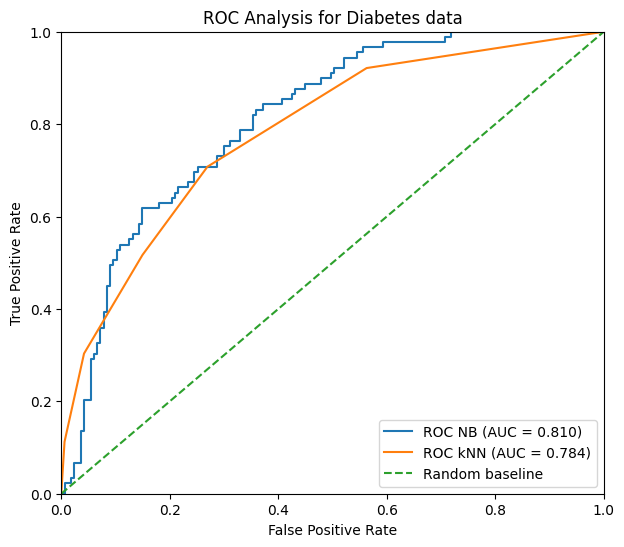

In [51]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# 1) Load data + build binary target
diDF = pd.read_csv("diabetes.csv")
diDF["target"] = np.where(diDF["neg_pos"] == "tested_positive", 1, 0)

# 2) X, y
X = diDF.drop(columns=["neg_pos", "target"]).values
y = diDF["target"].values

# 3) Split (stratify keeps class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=0, stratify=y
)

# 4) Scale (fit ONLY on train)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 5) Naive Bayes ROC (NB does not need scaling, but OK to use the same X_train_s/X_test_s for consistency)
gnb = GaussianNB()
y_score_nb = gnb.fit(X_train_s, y_train).predict_proba(X_test_s)[:, 1]  # P(class=1)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_score_nb, pos_label=1)
auc_nb = auc(fpr_nb, tpr_nb)

# 6) kNN ROC (kNN DOES need scaling)
knn = KNeighborsClassifier(n_neighbors=5, weights="uniform")
y_score_knn = knn.fit(X_train_s, y_train).predict_proba(X_test_s)[:, 1]  # P(class=1)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn, pos_label=1)
auc_knn = auc(fpr_knn, tpr_knn)

# 7) Plot ROC curves
plt.figure(figsize=(7, 6))
plt.plot(fpr_nb,  tpr_nb,  label=f"ROC NB (AUC = {auc_nb:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"ROC kNN (AUC = {auc_knn:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Analysis for Diabetes data")
plt.legend(loc="lower right")
plt.show()

# Q5-B: On synthetic data, where classes are geometrically separable in the feature space, **kNN** achieves better classification performance **(AUC ≈ 0.795)** than **Naive Bayes (AUC ≈ 0.752)**, which is sensitive to violations of the Gaussian distribution assumption.

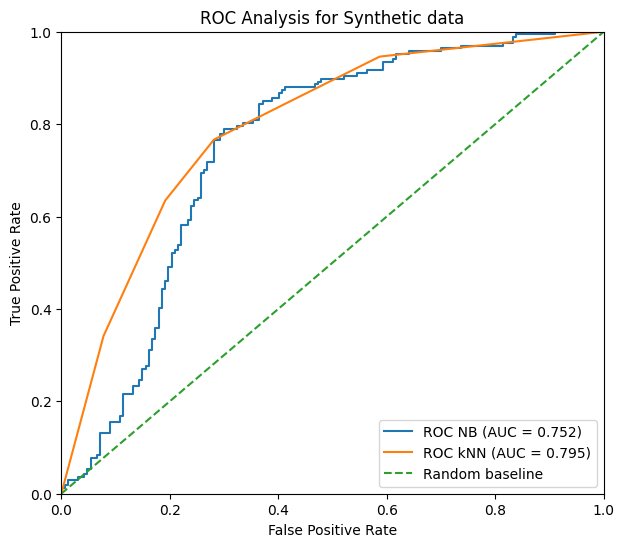

In [52]:
# ROC for SYNTHETIC data (Naive Bayes vs kNN) — same template as ROC notebook

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1) Generate synthetic data
X, y = make_classification(
    n_samples=1000, n_features=4, n_classes=2,
    class_sep=0.75, random_state=1
)

# 2) Split (fix randomness)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=0, stratify=y
)

# 3) Naive Bayes ROC (no scaling needed)
gnb = GaussianNB()
y_score_nb = gnb.fit(X_train, y_train).predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_score_nb, pos_label=1)
auc_nb = auc(fpr_nb, tpr_nb)

# 4) kNN ROC (scale AFTER split, fit scaler only on train)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5, weights="uniform")
y_score_knn = knn.fit(X_train_s, y_train).predict_proba(X_test_s)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn, pos_label=1)
auc_knn = auc(fpr_knn, tpr_knn)

# 5) Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr_nb,  tpr_nb,  label=f"ROC NB (AUC = {auc_nb:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"ROC kNN (AUC = {auc_knn:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Analysis for Synthetic data")
plt.legend(loc="lower right")
plt.show()

# Q6-A: Accuracy: M1 = 0.65 < M2 = 0.665

In [53]:
import pandas as pd

# M1 confusion matrix
M1 = pd.DataFrame(
    [[59, 41],
     [29, 71]],
    index=["Real_N", "Real_P"],
    columns=["Pred_N", "Pred_P"]
)

# M2 confusion matrix
M2 = pd.DataFrame(
    [[70, 30],
     [37, 63]],
    index=["Real_N", "Real_P"],
    columns=["Pred_N", "Pred_P"]
)

print("M1")
display(M1)

print("M2")
display(M2)

M1


,Pred_N,Pred_P
Real_N,59,41
Real_P,29,71


M2


,Pred_N,Pred_P
Real_N,70,30
Real_P,37,63


In [54]:
def accuracy(cm):
    TN = cm.loc["Real_N","Pred_N"]
    TP = cm.loc["Real_P","Pred_P"]
    total = cm.values.sum()
    return (TN + TP) / total

acc_M1 = accuracy(M1)
acc_M2 = accuracy(M2)

print("M1 accuracy =", round(acc_M1,3))
print("M2 accuracy =", round(acc_M2,3))

M1 accuracy = 0.65
M2 accuracy = 0.665


# Q6-B: True Positive Rate: M1 = 0.71 > M2 = 0.63

In [55]:
def TPR(cm):
    TP = cm.loc["Real_P","Pred_P"]
    FN = cm.loc["Real_P","Pred_N"]
    return TP / (TP + FN)

tpr_M1 = TPR(M1)
tpr_M2 = TPR(M2)

print("M1 TPR =", round(tpr_M1,3))
print("M2 TPR =", round(tpr_M2,3))

M1 TPR = 0.71
M2 TPR = 0.63


# Q6-C: Precision score (for positive class): M1 = 0.634 < M2 = 0.677

In [56]:
# Confusion matrices
# M1: [[TN, FP],
#      [FN, TP]]
M1 = [[59, 41],
      [29, 71]]

M2 = [[70, 30],
      [37, 63]]

# function
def precision_pos(cm):
    TN, FP = cm[0]
    FN, TP = cm[1]
    return TP / (TP + FP)

prec_M1 = precision_pos(M1)
prec_M2 = precision_pos(M2)

print("Precision M1:", round(prec_M1, 3))
print("Precision M2:", round(prec_M2, 3))

Precision M1: 0.634
Precision M2: 0.677




---

